In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\graci\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df = pd.read_csv('GOOG.csv')  # use pandas to read your csv file

In [3]:
df.head()    # visualize the dataset first 10 rows and its atributes

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


In [4]:
new_training_df = df.iloc[:-259, 1:6]   # saves a new df without the last 259 lines i will use for test
new_training_df.to_csv('training.csv', index=False)

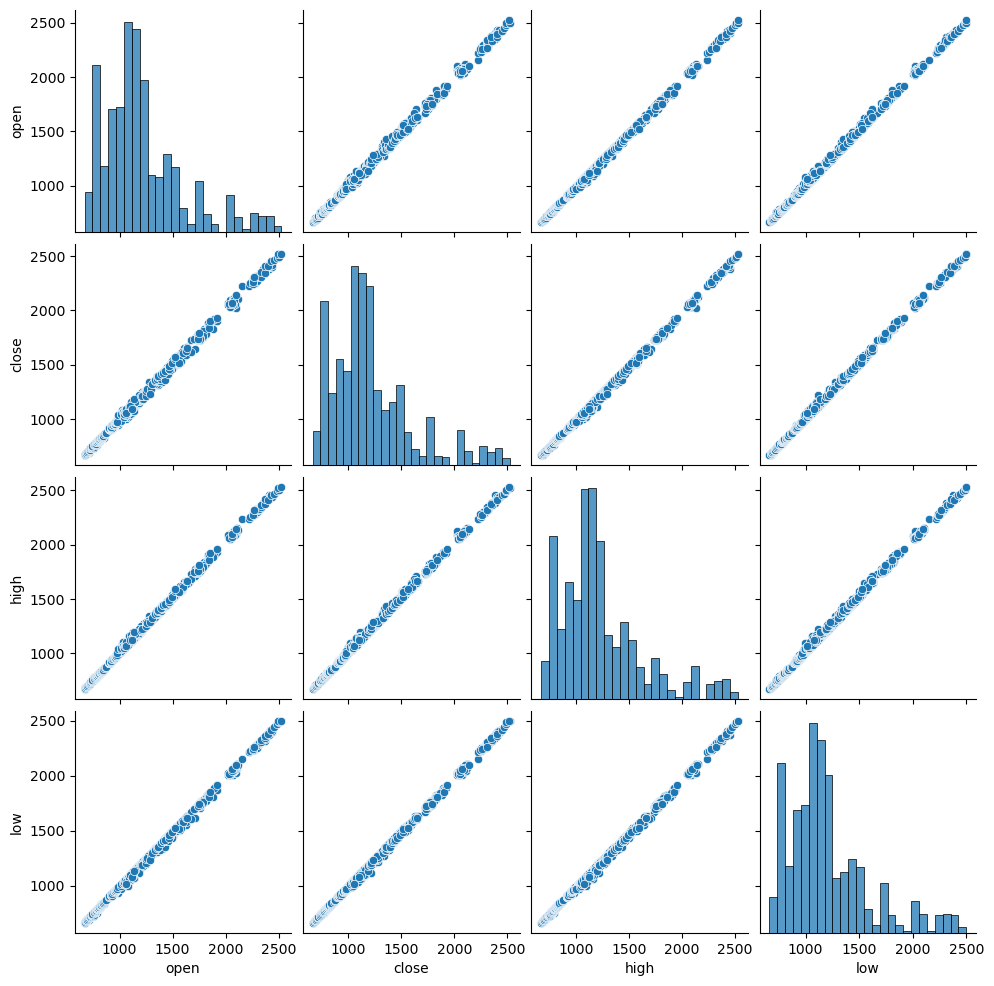

In [5]:
sns.pairplot(df[['date','open', 'close', 'high', 'low']])  # plot desired atributes

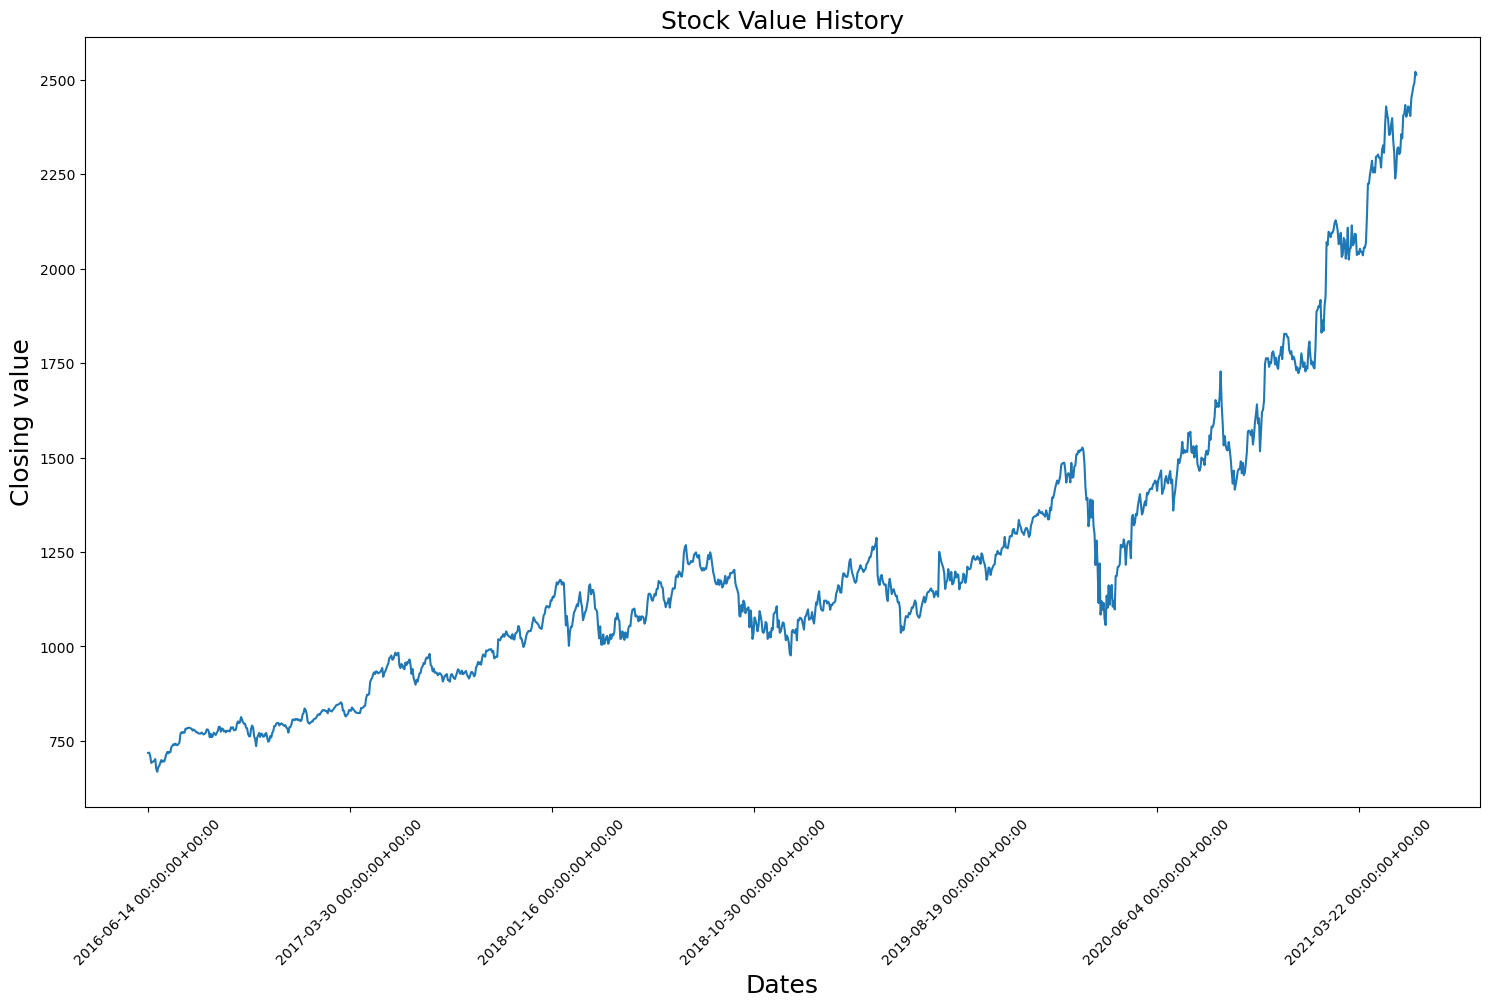

In [6]:
plt.figure(figsize= (18, 10))  # my figure size
plt.plot(df['close'])       # which attribute i want analyze
plt.xticks(range(0,df.shape[0],200), df['date'].loc[::200], rotation=45) # define what you wanna see in x axis
plt.title("Stock Value History", fontsize=18)
plt.xlabel('Dates', fontsize=18)
plt.ylabel('Closing value', fontsize=18)
plt.show()

In [7]:
df.shape

(1258, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [9]:
df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
mean,1216.317067,1227.430934,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,383.333358,387.570872,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,668.260000,672.300000,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,960.802500,968.757500,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0
max,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,0.0,1.0


In [10]:
test_data = df.iloc[1000:, 1:6]  # create a new df for testing data, using 20% of it 

In [11]:
test_data

,date,close,high,low,open
1000,2020-06-04 00:00:00+00:00,1412.18,1438.960,1404.7300,1430.40
1001,2020-06-05 00:00:00+00:00,1438.39,1445.050,1406.0000,1413.17
1002,2020-06-08 00:00:00+00:00,1446.61,1447.990,1422.3400,1422.34
1003,2020-06-09 00:00:00+00:00,1456.16,1468.000,1443.2100,1445.36
1004,2020-06-10 00:00:00+00:00,1465.85,1474.260,1456.2700,1459.54
...,...,...,...,...,...
1253,2021-06-07 00:00:00+00:00,2466.09,2468.000,2441.0725,2451.32
1254,2021-06-08 00:00:00+00:00,2482.85,2494.495,2468.2400,2479.90
1255,2021-06-09 00:00:00+00:00,2491.40,2505.000,2487.3300,2499.50
1256,2021-06-10 00:00:00+00:00,2521.60,2523.260,2494.0000,2494.01


In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
test_data.to_csv('testing_df.csv', index= False)  # save it as a new df

#### Select the desired atribute from the data frame and store it in a numpy array

In [14]:
training_df = df.iloc[0:999, 2].values  # select the variable we want to predict for a new dataset in a numpy array format

In [15]:
type(training_df)   # check if is in the right format 

numpy.ndarray

### Import libraries to apply feature scaling to the dataset
##### using normalization as the stock prices doesn't follow a Gaussian distribution

In [16]:
from sklearn.preprocessing import MinMaxScaler 

In [17]:
data_scaler = MinMaxScaler()   # create an instance of this class to a variable called scaler

In [18]:
training_df = data_scaler.fit_transform(training_df.reshape(-1, 1))  # modify original dataset

In [19]:
x_train = []    # x will hold the 30 days before (timesteps=30) used to make prediction
y_train = []    # y hold data of the price for next day, the dat that the RNN is trying to predict  

In [20]:
for i in range(40, len(training_df)):      # loop to populate the data iterate from 30 to the last index
    x_train.append(training_df[i-40:i,0])  # check the 30 preceding data(close prices)
    y_train.append(training_df[i, 0])      # loop to append the next day stock price

In [21]:
x_train = np.array(x_train)  # transform data into numpy array
y_train = np.array(y_train)

In [22]:
print(x_train.shape)  # verify the data shape, x is expected to be 2D array, one holding the timesteps 
print(y_train.shape)   # and the other dimension being the length (total - 30)

(959, 40)
(959,)


In [23]:
# reshape the object to build the recurent neural network 
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [24]:
print(x_train.shape)

(959, 40, 1)


### simple RNN model

In [25]:
# !pip install tensorflow          # import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import SimpleRNN
# from tensorflow.keras.layers import GRU   # in case i want compare a third model 

In [26]:
rnn = Sequential() 
# initializes object from tensorflow's sequential class,
# which is designed to build neural networks by over time adding sequences of layers

In [27]:

# LSTM = long short-term memory, used to solve the vanishing gradient problem
# lstm units is the n of neurons i want include in the layer, to increase dimensionality
rnn.add(SimpleRNN(units = 35, return_sequences = 'TRUE', input_shape = (x_train.shape[1], 1),activation='relu')) # adding a neu layer to the rnn model

C:\Users\graci\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
# rnn.add(LSTM(units = 35, return_sequences = True))
# rnn.add(Dropout(0.2)) 

for i in [True, True, False]: 
    rnn.add(SimpleRNN(units = 35, return_sequences = i, activation ='relu'))
    rnn.add(Dropout(0.2)) 
    
# to avoid overfitting, add dropout regularization (it excludes certain layers during training) 
# normally used 20% = rnn.add(Dropout(0.2))  

In [29]:
# add the output layer(Dense) for the RNN, as we want output a single value ['close'], one dimension (units = 1)
rnn.add(Dense(units = 1, activation='sigmoid'))     # the last layer we using sigmoid activation function which is the deffault one

In [30]:
rnn.compile(optimizer = 'adam', loss = 'mean_squared_error') #compile rnn

In [31]:
test_data = np.array(test_data)

In [32]:
rnn.fit(x_train, y_train, epochs = 100, batch_size = 32)  # fitting rnn

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0465
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0215
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0044
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0038
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023
Ep

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 
Epoch 83/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 84/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012
Epoch 85/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 86/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 87/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014
Epoch 88/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 
Epoch 89/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 90/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch 91/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 
Epoch 92/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 
Epoch 93/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 94/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016
Epoch 95/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 
Epoch 96/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011  
E

In [33]:
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 40, 35)              │           1,295 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 40, 35)              │           2,485 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 35)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 40, 35)              │           2,485 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 40, 35)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 35)                  │           2,485 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 35)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,360 (102.97 KB)

 Trainable params: 8,786 (34.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,574 (68.65 KB)

### Now finally, make the prediction and compare to the actual values:

In [34]:
test = pd.read_csv('testing_df.csv')

In [35]:
test.head()

,date,close,high,low,open
0,2020-06-04 00:00:00+00:00,1412.18,1438.96,1404.73,1430.40
1,2020-06-05 00:00:00+00:00,1438.39,1445.05,1406.00,1413.17
2,2020-06-08 00:00:00+00:00,1446.61,1447.99,1422.34,1422.34
3,2020-06-09 00:00:00+00:00,1456.16,1468.00,1443.21,1445.36
4,2020-06-10 00:00:00+00:00,1465.85,1474.26,1456.27,1459.54


In [36]:
test = test.iloc[:,1].values

In [37]:
print(test.shape)

(258,)


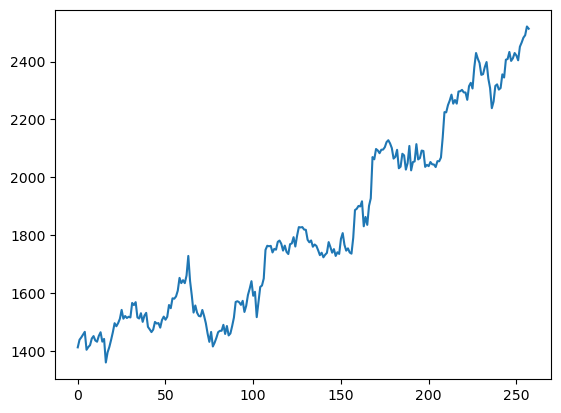

In [38]:
plt.plot(test)
plt.show()

In [39]:
unscaled_train_db = pd.read_csv('training.csv') # import the datasets again as we cannot concat a dataset that was applied feature scaling
unscaled_test_db = pd.read_csv('testing_df.csv')

In [40]:
print(unscaled_train_db.shape)
print(unscaled_test_db.shape)

(999, 5)
(258, 5)


In [41]:
my_data=pd.concat((unscaled_train_db['close'], # concatenate together the desired column
unscaled_test_db['close']), axis = 0)  # axis=0, the concatenation happens vertically

In [42]:
x_test = my_data[len(my_data) - len(test) - 40:].values #finds the index of first trading day

In [43]:
x_test = np.reshape(x_test, (-1, 1))  # reshape Numpy array for use in the predict method

In [44]:
print(x_test.shape)

(298, 1)


In [45]:
x_test = data_scaler.transform(x_test)  # scales from 0 to 1 the data

In [46]:
final_x_test = []
for i in range(40, len(x_test)):
    final_x_test.append(x_test[i-40:i, 0])
final_x_test = np.array(final_x_test)

In [47]:
final_x_test = np.reshape(final_x_test,
(final_x_test.shape[0], final_x_test.shape[1],1))

In [48]:
predicting_data = rnn.predict(final_x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


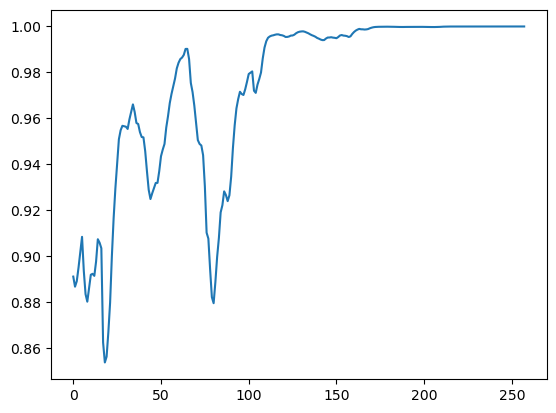

In [49]:
plt.plot(predicting_data) 
plt.show()

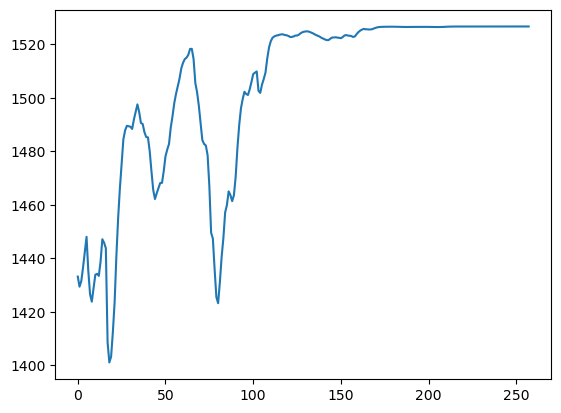

In [50]:
unscaled_prediction = data_scaler.inverse_transform(predicting_data)
plt.plot(unscaled_prediction)
plt.show()

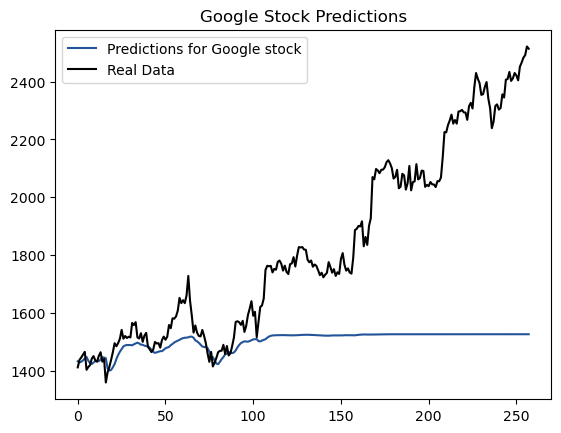

In [51]:
plt.plot(unscaled_prediction, color = '#235499', label = "Predictions for Google stock")
plt.plot(test, color = 'black', label = "Real Data")
plt.title('Google Stock Predictions')
plt.legend()
plt.show()

### LSTM model

In [54]:
lstm = Sequential() 

In [55]:
lstm.add(LSTM(units = 35, return_sequences = 'TRUE', input_shape = (x_train.shape[1], 1),activation='relu'))

C:\Users\graci\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
for i in [True, True, False]: 
    lstm.add(LSTM(units = 35, return_sequences = i, activation ='relu'))
    lstm.add(Dropout(0.2)) 

In [57]:
#lstm.add(LSTM(units = 45, return_sequences = True))

#lstm.add(Dropout(0.2))

#lstm.add(LSTM(units = 45, return_sequences = True))

#lstm.add(Dropout(0.2))

#lstm.add(LSTM(units = 45))

#lstm.add(Dropout(0.2))

In [58]:
lstm.add(Dense(units = 1, activation='sigmoid'))

In [59]:
lstm.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [60]:
testing_data = np.array(test_data)

In [61]:
lstm.fit(x_train, y_train, epochs = 100, batch_size = 32) 

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0455
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0096
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0078
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0068
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0071
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0065
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0049
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0057
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0045
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0054
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0040
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0043
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0038
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - lo

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0021
Epoch 82/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020
Epoch 83/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019
Epoch 84/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019
Epoch 85/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0021
Epoch 86/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018
Epoch 87/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019
Epoch 88/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020
Epoch 89/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0018
Epoch 90/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018
Epoch 91/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0020
Epoch 92/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0017
Epoch 93/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018
Epoch 94/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020
Epoch 95/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 

In [62]:
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 40, 35)              │           5,180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 40, 35)              │           9,940 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 40, 35)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 40, 35)              │           9,940 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 40, 35)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 35)                  │           9,940 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 35)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,110 (410.59 KB)

 Trainable params: 35,036 (136.86 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,074 (273.73 KB)

In [63]:
predicting_data = lstm.predict(final_x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


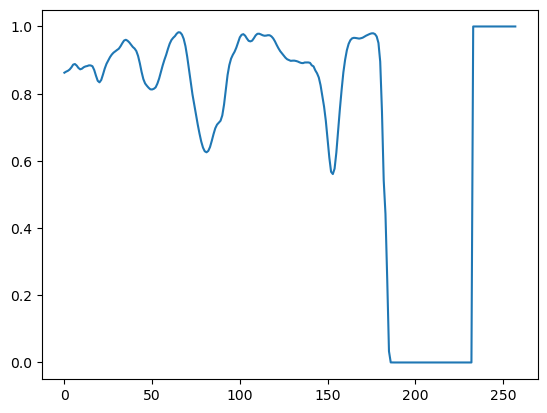

In [64]:
plt.plot(predicting_data) 
plt.show()

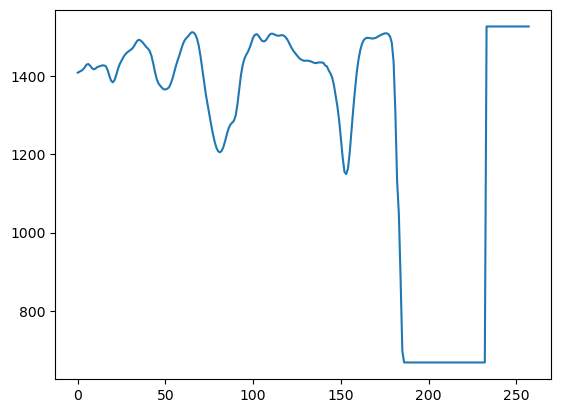

In [65]:
unscaled_prediction = data_scaler.inverse_transform(predicting_data)
plt.plot(unscaled_prediction)
plt.show()

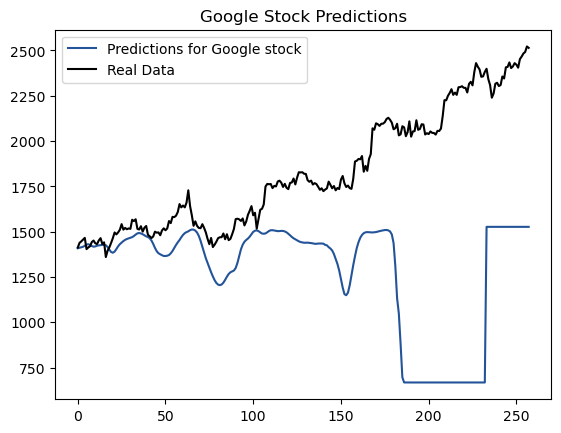

In [66]:
plt.plot(unscaled_prediction, color = '#235499', label = "Predictions for Google stock")
plt.plot(test, color = 'black', label = "Real Data")
plt.title('Google Stock Predictions')
plt.legend()
plt.show()